In [37]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Input, Dropout, GRU
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2

import re

import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')

## Load data & select features

In [38]:
df = pd.read_csv("../non_temporal_predictions/feature_engineering/data_with_new_features_v3.csv")
df

,timestamp,participant,heart_rate,x_coordinate,y_coordinate,pupil_diameter_mm,iris_diameter_mm,pupil_iris_ratio,head_displacement,head_velocity,...,iris_diameter_mm_normal_normal,pupil_iris_ratio_high_high,pupil_iris_ratio_high_normal,pupil_iris_ratio_low_high,pupil_iris_ratio_low_low,pupil_iris_ratio_low_normal,pupil_iris_ratio_normal_high,pupil_iris_ratio_normal_low,pupil_iris_ratio_normal_normal,genre
0,2025-06-05 16:25:55,kenji,62.000000,409.206897,194.000000,2.602941,11.8,0.220588,0.000000,0.000000,...,2782,464,27,1,288,26,26,27,1923,comedy
1,2025-06-05 16:25:56,kenji,61.500000,413.433333,194.800000,2.602941,11.8,0.220588,4.301484,4.301484,...,2782,464,27,1,288,26,26,27,1923,comedy
2,2025-06-05 16:25:59,kenji,60.000000,397.333333,191.000000,2.602941,11.8,0.220588,16.542370,5.514123,...,2782,464,27,1,288,26,26,27,1923,comedy
3,2025-06-05 16:26:01,kenji,60.000000,397.166667,190.600000,2.602941,11.8,0.220588,0.433333,0.216667,...,2782,464,27,1,288,26,26,27,1923,comedy
4,2025-06-05 16:26:04,kenji,60.000000,391.000000,189.333333,2.602941,11.8,0.220588,6.295413,2.098471,...,2782,464,27,1,288,26,26,27,1923,comedy
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9339,2025-06-12 10:33:03,aimen,69.555556,354.483871,323.258065,2.726626,11.8,0.231070,0.965066,0.965066,...,2450,444,28,0,401,29,29,29,1490,horror
9340,2025-06-12 10:33:04,aimen,69.666667,354.600000,324.000000,2.726626,11.8,0.231070,0.750969,0.750969,...,2450,444,28,0,401,29,29,29,1490,horror
9341,2025-06-12 10:33:05,aimen,69.777778,355.000000,323.931034,2.726626,11.8,0.231070,0.405902,0.405902,...,2450,444,28,0,401,29,29,29,1490,horror
9342,2025-06-12 10:33:06,aimen,69.888889,355.500000,323.900000,2.726626,11.8,0.231070,0.500962,0.500962,...,2450,444,28,0,401,29,29,29,1490,horror


In [39]:
def select_feature_groups(df, group_names):
    base = ['timestamp', 'participant', 'genre']
    groups = {
        "raw": [
            'heart_rate', 'x_coordinate', 'y_coordinate', 'pupil_diameter_mm',
            'iris_diameter_mm', 'pupil_iris_ratio'],
        'head_movement':['head_displacement', 'head_velocity', 'head_direction_change_rate', 'head_stability', 'centered_x', 'centered_y'],
    }
    selected = set(base)
    for name in group_names:
        selected.update(groups.get(name, []))
    return df[list(selected)]

df = select_feature_groups(df, ['raw', 'head_movement'])

## Data Preprocessing

In [40]:
# Encode genre
le = LabelEncoder()
df['genre'] = le.fit_transform(df['genre'])

# Features
exclude_cols = ['timestamp', 'participant', 'genre']
numeric_cols = df.select_dtypes(include='number').columns
features = [col for col in numeric_cols if col not in exclude_cols]

# Train/test based on participant
df_train = df[df['participant'] != 'clara'].copy()
df_test = df[df['participant'] == 'clara'].copy()

# Normalize features
scaler = StandardScaler()
df_train[features] = scaler.fit_transform(df_train[features])
df_test[features] = scaler.transform(df_test[features])

## Train/Val/Test Split

In [41]:
def split_each_session(df, val_ratio=0.2):
    train_parts = []
    val_parts = []
    
    # group by session (participant, genre)
    for _, group in df.groupby(['participant', 'genre']):
        group = group.sort_values('timestamp')
        split_idx = int(len(group) * (1 - val_ratio))
        train_parts.append(group.iloc[:split_idx])
        val_parts.append(group.iloc[split_idx:])
    
    df_train_final = pd.concat(train_parts)
    df_val = pd.concat(val_parts)
    
    return df_train_final, df_val

df_train_final, df_val = split_each_session(df_train, val_ratio=0.2)

## Setup, Build, & Train Model

In [42]:
def create_sequences(df, seq_len=5):
    X, y = [], []
    for _, group in df.groupby(['participant', 'genre']):
        group = group.sort_values('timestamp')
        values = group[features].values
        label = group['genre'].iloc[0]
        for i in range(len(values) - seq_len):
            X.append(values[i:i+seq_len])
            y.append(label)
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.int32)

X_train_final, y_train_final = create_sequences(df_train_final)
X_val, y_val = create_sequences(df_val)
X_test, y_test = create_sequences(df_test)

In [43]:
# Build LSTM model
model = Sequential()
model.add(LSTM(32, activation='relu', input_shape=(X_train_final.shape[1], X_train_final.shape[2]), return_sequences=False))
model.add(Dropout(0.2))
# model.add(LSTM(50, activation='relu')) 
# model.add(Dropout(0.2))
model.add(Dense(16, activation='relu', kernel_regularizer=l2(0.01)))  # added dense layer
model.add(Dense(len(np.unique(y_train_final)), activation='softmax'))

optimizer = Adam(learning_rate=1e-4)
model.compile(optimizer=optimizer, loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Train
early_stop = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)

history = model.fit(
    X_train_final, y_train_final,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=64,
    verbose=1,
    callbacks=[early_stop],
    shuffle=False
)

Epoch 1/100
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.1563 - loss: 1.3572 - val_accuracy: 0.2343 - val_loss: 1.3390
Epoch 2/100
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.2154 - loss: 1.3213 - val_accuracy: 0.2686 - val_loss: 1.3181
Epoch 3/100
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.2945 - loss: 1.2937 - val_accuracy: 0.3020 - val_loss: 1.2995
Epoch 4/100
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.3967 - loss: 1.2659 - val_accuracy: 0.3451 - val_loss: 1.2814
Epoch 5/100
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.4568 - loss: 1.2452 - val_accuracy: 0.3902 - val_loss: 1.2629
Epoch 6/100
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.5461 - loss: 1.2233 - val_accuracy: 0.4039 - val_loss: 1.2437
Epoch 7/100
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.5757 - loss: 1.1957 - val_accuracy: 0.4098 - val_loss: 1.2238
Epoch 8/100
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6050 - loss: 1.1685 - val_accuracy: 0.4333 - v

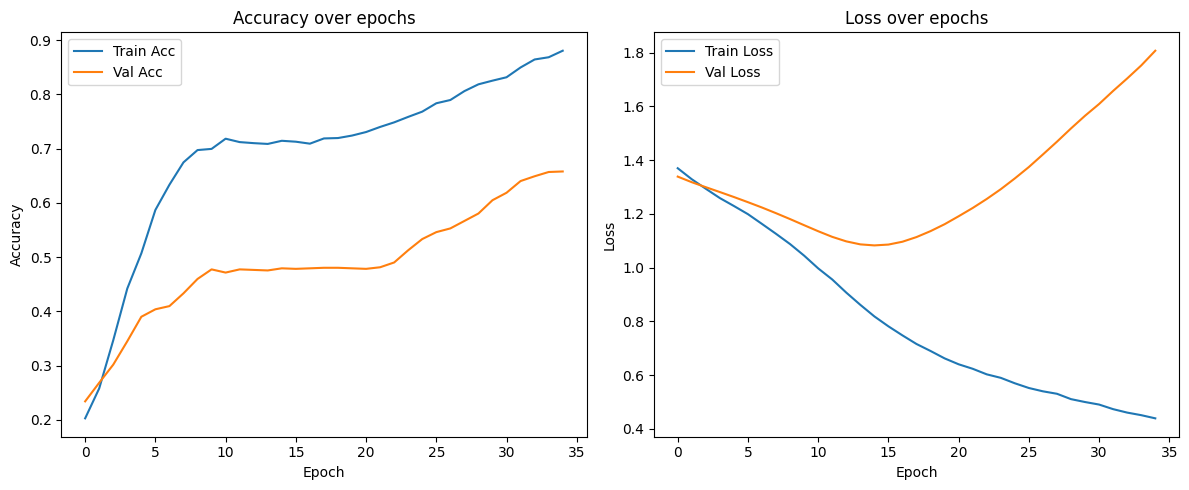

In [44]:
# Plot accuracy and loss
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title('Accuracy over epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss over epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

In [45]:
# Evaluate
y_pred = model.predict(X_test)
y_pred_labels = np.argmax(y_pred, axis=1)
print(classification_report(y_test, y_pred_labels, target_names=le.classes_, zero_division=0))

129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
              precision    recall  f1-score   support

      comedy       1.00      0.00      0.00      1335
 documentary       0.40      0.94      0.56      1555
      horror       0.67      0.24      0.35      1207

    accuracy                           0.43      4097
   macro avg       0.69      0.39      0.30      4097
weighted avg       0.67      0.43      0.32      4097



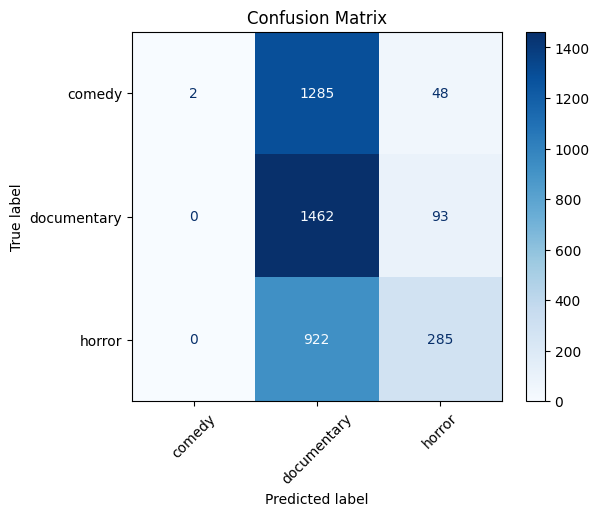

In [46]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred_labels)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(xticks_rotation=45, cmap='Blues')
plt.title('Confusion Matrix')
plt.show()